<a href="https://colab.research.google.com/github/canevadop-dev/proyecto-datamining/blob/main/Limpiezadedatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


---
# Curso: Data Mining - Semana 2

Integrantes : Rosalinda Salva Vasquez
              Cristina Nevado Perez

---

<a name='manejoarchivos'></a>
# <font color=blue> Limpieza inicial de datos e integración básica</font>

### <font color=green> 1. Importar datos </font>
Archivos usados:
- `Tasa y número de desertores en Educación Primaria 2023-2024.csv`: datos de desertores de Educación Primaria
- `Tasa y número de desertores en Educación Secundaria 2023-2024.csv`: datos de desertores de Educación Primaria

La llave de integración será `ubigeo`.


# **1. Descripción del problema y unidad de análisis**

La deserción escolar no se distribuye de manera constante entre los departamentos del Perú. Existen departamentos con comportamientos diferentes que no son evidentes al observar la tabla de datos.

**Unidad de análisis** : Departamento

# **Fuentes de datos usadas**

Los dataset de Tasa y número de desertores en Educación Primaria y Secundaria 2023/2024.
https://www.datosabiertos.gob.pe/dataset/tasa-y-n%C3%BAmero-de-desertores-en-educaci%C3%B3n-primaria-y-secundaria-20232024

# **Llave posible de integración.**


Ubigeo (la llave para integrar las tablas), departamento, provincia y distrito.

# **Inspección inicial**


Revisamos tamaño, tipos de datos y estadísticas descriptivas.

In [ ]:
print("Tamaño de primaria:", primaria.shape)
print("Tamaño de secundaria:", secundaria.shape)

print("\nTipos detectados en primaria:")
display(primaria.dtypes)

print("\nTipos detectados en secundaria:")
display(secundaria.dtypes)

Tamaño de primaria: (1890, 7)
Tamaño de secundaria: (1846, 7)

Tipos detectados en primaria:


,0
ubigeo,int64
Departamento,object
Provincia,object
Distrito,object
desertor,int64
denominador,int64
Tasa,float64



Tipos detectados en secundaria:


,0
ubigeo,int64
Departamento,object
Provincia,object
Distrito,object
desertor,int64
denominador,int64
Tasa,float64


In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [ ]:
primaria = pd.read_csv("/content/Tasa y número de desertores en Educación Primaria 2023-2024.csv")
secundaria = pd.read_csv("/content/Tasa y número de desertores en Educación Secundaria 2023-2024.csv")
print("Tabla de Educación Primaria:")
display(primaria.head())
print("Tabla de Educación Secuandaria:")
display(secundaria.head())

Tabla de Educación Primaria:


,ubigeo,Departamento,Provincia,Distrito,desertor,denominador,Tasa
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,17,4146,0.410034
1,10102,AMAZONAS,CHACHAPOYAS,ASUNCION,0,12,0.000000
2,10103,AMAZONAS,CHACHAPOYAS,BALSAS,0,168,0.000000
3,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,44,0.000000
4,10105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,3,62,4.838710


Tabla de Educación Secuandaria:


,ubigeo,Departamento,Provincia,Distrito,desertor,denominador,Tasa
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,42,3421,1.227711
1,10103,AMAZONAS,CHACHAPOYAS,BALSAS,5,125,4.000000
2,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,54,0.000000
3,10106,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,7,171,4.093567
4,10107,AMAZONAS,CHACHAPOYAS,GRANADA,0,62,0.000000


# **3. Tabla resumen de cada fuente**

In [ ]:
print("Resumen de educación primaria:")
display(primaria.describe(include="all").T)

print("Resumen de educación secundaria:")
display(secundaria.describe(include="all").T)


Resumen de educación primaria:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ubigeo,1890.0,NaN,NaN,NaN,106801.355556,67175.092961,10101.0,50403.25,100314.5,150805.75,250401.0
Departamento,1890,25,LIMA,171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Provincia,1890,196,LIMA,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distrito,1890,1734,SANTA ROSA,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desertor,1890.0,NaN,NaN,NaN,34.107407,151.953643,0.0,0.0,2.0,12.75,2720.0
denominador,1890.0,NaN,NaN,NaN,1969.233862,5909.599158,4.0,149.25,418.5,1358.25,114605.0
Tasa,1890.0,NaN,NaN,NaN,0.933455,1.246826,0.0,0.0,0.555042,1.281232,12.476008


Resumen de educación secundaria:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ubigeo,1846.0,NaN,NaN,NaN,107668.643554,66838.629145,10101.0,50506.25,100401.5,150811.75,250401.0
Departamento,1846,25,LIMA,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Provincia,1846,196,LIMA,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distrito,1846,1697,SANTA ROSA,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
desertor,1846.0,NaN,NaN,NaN,39.156013,129.368646,0.0,1.0,5.0,25.0,2090.0
denominador,1846.0,NaN,NaN,NaN,1539.995125,4575.614746,7.0,131.0,357.0,1054.5,86526.0
Tasa,1846.0,NaN,NaN,NaN,2.045636,2.171093,0.0,0.280249,1.550388,3.089325,18.644068


**Tabla resumen de las fuentes**

In [ ]:
resumen_df1 = pd.DataFrame({
    "fuente": "fuente1_estudiantes",
    "variable": primaria.columns,
    "tipo_python": primaria.dtypes.values,
    "n_faltantes":primaria.isnull().sum().values,
    "porcentaje_faltantes": (primaria.isnull().mean() * 100).round(2).values,
    "valores_distintos": primaria.nunique().values
})

resumen_df2 = pd.DataFrame({
    "fuente": "fuente2_academica",
    "variable": secundaria.columns,
    "tipo_python": secundaria.dtypes.values,
    "n_faltantes": secundaria.isnull().sum().values,
    "porcentaje_faltantes": ((secundaria).isnull().mean() * 100).round(2).values,
    "valores_distintos": secundaria.nunique().values
})

tabla_resumen_fuentes = pd.concat([resumen_df1, resumen_df2], ignore_index=True)
#Nota: ignore_index=True hace que Pandas cree un nuevo índice consecutivo al unir las tablas.

print("Tabla resumen de las fuentes:")
display(tabla_resumen_fuentes)

Tabla resumen de las fuentes:


,fuente,variable,tipo_python,n_faltantes,porcentaje_faltantes,valores_distintos
0,fuente1_estudiantes,ubigeo,int64,0,0.0,1890
1,fuente1_estudiantes,Departamento,object,0,0.0,25
2,fuente1_estudiantes,Provincia,object,0,0.0,196
3,fuente1_estudiantes,Distrito,object,0,0.0,1734
4,fuente1_estudiantes,desertor,int64,0,0.0,196
5,fuente1_estudiantes,denominador,int64,0,0.0,1148
6,fuente1_estudiantes,Tasa,float64,0,0.0,1166
7,fuente2_academica,ubigeo,int64,0,0.0,1846
8,fuente2_academica,Departamento,object,0,0.0,25
9,fuente2_academica,Provincia,object,0,0.0,196


# **4. Problemas detectados**
# **Valores faltantes**
Primero detectamos; todavía no corregimos.

Ambas tablas, correspondientes a educación primaria y secundaria, se encuentran completas y no presentan valores faltantes.

In [ ]:
faltantes_primaria = pd.DataFrame({
    "n_faltantes": primaria.isna().sum(),
    "porcentaje": (primaria.isna().mean() * 100).round(2)
})

faltantes_secundaria = pd.DataFrame({
    "n_faltantes": secundaria.isna().sum(),
    "porcentaje": (secundaria.isna().mean() * 100).round(2)
})

print("Faltantes en primaria")
display(faltantes_primaria)

print("Faltantes en secundaria")
display(faltantes_secundaria)


Faltantes en primaria


,n_faltantes,porcentaje
ubigeo,0,0.0
Departamento,0,0.0
Provincia,0,0.0
Distrito,0,0.0
desertor,0,0.0
denominador,0,0.0
Tasa,0,0.0


Faltantes en secundaria


,n_faltantes,porcentaje
ubigeo,0,0.0
Departamento,0,0.0
Provincia,0,0.0
Distrito,0,0.0
desertor,0,0.0
denominador,0,0.0
Tasa,0,0.0


##**Categorías y errores de registro**




Revisamos valores distintos en variables categóricas. Esto ayuda a encontrar codificaciones no uniformes.

In [ ]:
print("Valores de Departamento:")
display(primaria["Departamento"].value_counts(dropna=False))

print("Valores de Provincia:")
display(primaria["Provincia"].value_counts(dropna=False))

print("Valores de Distrito:")
display(primaria["Distrito"].value_counts(dropna=False))

#print("Valores de cliente_activo:")
#display(compras["cliente_activo"].value_counts(dropna=False))

Valores de Departamento:


,count
Departamento,
LIMA,171
ANCASH,166
CAJAMARCA,127
JUNIN,124
AYACUCHO,124
CUSCO,116
PUNO,110
AREQUIPA,109
HUANCAVELICA,102


Valores de Provincia:


,count
Provincia,
LIMA,43
JAUJA,34
YAUYOS,33
HUAROCHIRI,32
AREQUIPA,29
...,...
TAHUAMANU,3
CONTRALMIRANTE VILLAR,3
JORGE BASADRE,3


Valores de Distrito:


,count
Distrito,
SANTA ROSA,10
SAN ANTONIO,6
SANTA CRUZ,5
PUEBLO NUEVO,5
SAN CRISTOBAL,4
...,...
LA RAMADA,1
CUJILLO,1
CHOROS,1


##**Duplicados**

Distinguimos duplicados exactos y duplicados por clave (`ubigeo`).

In [ ]:
print("Filas duplicadas exactas en Primaria:", primaria.duplicated().sum())
print("Filas duplicadas exactas en Secundaria:", secundaria.duplicated().sum())

print("\nUbigeo repetidos en primaria:")
display(primaria[primaria.duplicated(subset=["ubigeo"], keep=False)].sort_values("ubigeo"))

print("\nUbigeo repetidos en primaria:")
display(secundaria[secundaria.duplicated(subset=["ubigeo"], keep=False)].sort_values("ubigeo"))


Filas duplicadas exactas en Primaria: 0
Filas duplicadas exactas en Secundaria: 0

Ubigeo repetidos en primaria:


,ubigeo,Departamento,Provincia,Distrito,desertor,denominador,Tasa



Ubigeo repetidos en primaria:


,ubigeo,Departamento,Provincia,Distrito,desertor,denominador,Tasa


No se encontraron registros duplicados en ninguno de los dos datasets, correspondientes a educación primaria y secundaria.

# **Verificar si hay outliers**

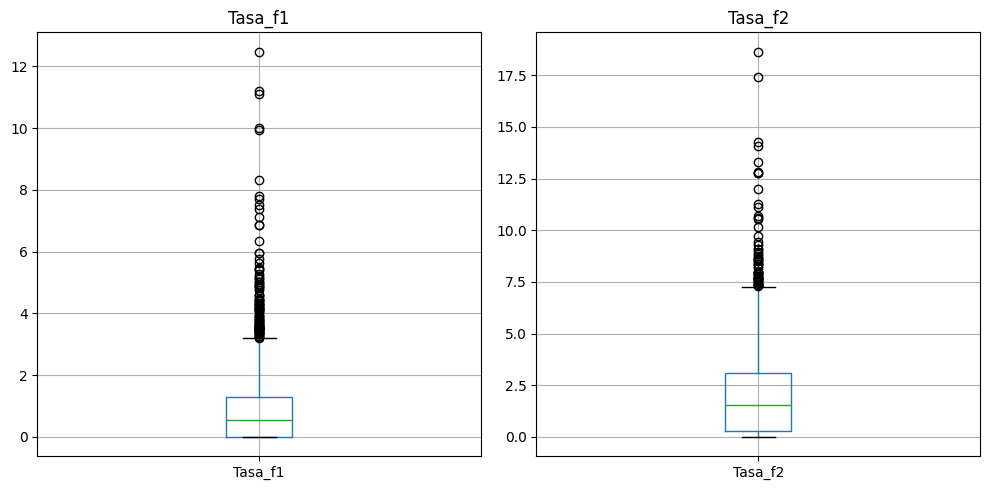

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
df.boxplot(column='Tasa_f1', ax=axes[0])
df.boxplot(column='Tasa_f2', ax=axes[1])
axes[0].set_title('Tasa_f1')
axes[1].set_title('Tasa_f2')
plt.tight_layout()
plt.show()

**Valores faltantes:**

Las fuentes originales no presentan datos faltantes. Sin embargo, después del merge, 44 distritos no tuvieron correspondencia en la fuente 2, generando valores NaN en sus variables correspondientes.
Duplicados: No se encontraron registros ni códigos ubigeo duplicados.

**Errores de registros:**
No se encontraron registros de datos

**Tipos de datos:**
ubigeo se encuentra en tipo string.
Asimismo, algunas variables numéricas quedaron como float64 debido a los valores faltantes generados por el merge.

 **Valores fuera de rango:**

No se encontraron valores negativos ni inconsistencias entre desertor y denominador. Las tasas también fueron verificadas y están correctamente calculadas.

**Outliers**

Se encontraron algunos valores atípicos en las tasas, principalmente asociados a distritos con pocos estudiantes. Estos no necesariamente representan errores.

**Categorías**

No se encontraron inconsistencias en los nombres de departamentos, provincias y distritos. Además, los registros que coincidieron entre ambas fuentes presentan la misma información geográfica.

# **5. Decisiones de limpieza justificadas**

**¿Qué se corrigió?**

Se corrigieron las columnas duplicadas que surgieron al combinar las llaves de ambas tablas, conservando la información correspondiente y evitando redundancias.

**¿Qué se imputó?**
No se realizó imputación de datos, debido a que no se encontraron valores faltantes en ninguno de los dos datasets.

**¿Qué se eliminó?**
Se eliminaron únicamente las columnas que contenían información duplicada como resultado de la combinación de ambas tablas, ya que mantenerlas generaría redundancia.

**¿Qué se mantuvo y por qué?**
Se mantuvieron los registros y valores de ambas tablas, debido a que no se encontraron datos faltantes ni registros duplicados. Por ello, no fue necesario eliminar observaciones.

##**6. Integración básica**

Unimos las fuentes usando `ubigeo`.

Usamos `how="outer"` para conservar todos los registros y ver cuáles aparecen en una fuente, en la otra o en ambas.

In [ ]:
base_integrada = pd.merge(
    primaria,
    secundaria,
    on="ubigeo",
    how="outer",
    suffixes=("_primaria", "_secundaria"),
    indicator=True
)

display(base_integrada)
display(base_integrada["_merge"].value_counts())


,ubigeo,Departamento_primaria,Provincia_primaria,Distrito_primaria,desertor_primaria,denominador_primaria,Tasa_primaria,Departamento_secundaria,Provincia_secundaria,Distrito_secundaria,desertor_secundaria,denominador_secundaria,Tasa_secundaria,_merge
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,17,4146,0.410034,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,42.0,3421.0,1.227711,both
1,10102,AMAZONAS,CHACHAPOYAS,ASUNCION,0,12,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2,10103,AMAZONAS,CHACHAPOYAS,BALSAS,0,168,0.000000,AMAZONAS,CHACHAPOYAS,BALSAS,5.0,125.0,4.000000,both
3,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,44,0.000000,AMAZONAS,CHACHAPOYAS,CHETO,0.0,54.0,0.000000,both
4,10105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,3,62,4.838710,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1885,250304,UCAYALI,PADRE ABAD,NESHUYA,37,2114,1.750237,UCAYALI,PADRE ABAD,NESHUYA,11.0,1507.0,0.729927,both
1886,250305,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,9,911,0.987925,UCAYALI,PADRE ABAD,ALEXANDER VON HUMBOLDT,32.0,619.0,5.169628,both
1887,250306,UCAYALI,PADRE ABAD,HUIPOCA,11,627,1.754386,UCAYALI,PADRE ABAD,HUIPOCA,0.0,300.0,0.000000,both
1888,250307,UCAYALI,PADRE ABAD,BOQUERON,9,674,1.335312,UCAYALI,PADRE ABAD,BOQUERON,10.0,568.0,1.760563,both


,count
_merge,
both,1846
left_only,44
right_only,0


##**6.1 Eliminar columnas duplicadas**

Una vez integrada la base, eliminamos las columnas de la fuente 'secundaria' que duplican la información de 'primaria' para evitar redundancia.

In [ ]:
base_integrada = base_integrada.drop(columns=[
    "Departamento_secundaria",
    "Provincia_secundaria",
    "Distrito_secundaria"
])

display(base_integrada.head())

,ubigeo,Departamento_primaria,Provincia_primaria,Distrito_primaria,desertor_primaria,denominador_primaria,Tasa_primaria,desertor_secundaria,denominador_secundaria,Tasa_secundaria,_merge
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,17,4146,0.410034,42.0,3421.0,1.227711,both
1,10102,AMAZONAS,CHACHAPOYAS,ASUNCION,0,12,0.000000,NaN,NaN,NaN,left_only
2,10103,AMAZONAS,CHACHAPOYAS,BALSAS,0,168,0.000000,5.0,125.0,4.000000,both
3,10104,AMAZONAS,CHACHAPOYAS,CHETO,0,44,0.000000,0.0,54.0,0.000000,both
4,10105,AMAZONAS,CHACHAPOYAS,CHILIQUIN,3,62,4.838710,NaN,NaN,NaN,left_only


##**7. Validación final**

Después de limpiar e integrar, volvemos a revisar tipos, faltantes y resumen.

In [ ]:
print("Tipos finales:")
display(base_integrada.dtypes)

print("Faltantes finales:")
display(base_integrada.isna().sum())

print("Resumen final:")
display(base_integrada.describe(include="all"))


Tipos finales:


,0
ubigeo,int64
Departamento_primaria,object
Provincia_primaria,object
Distrito_primaria,object
desertor_primaria,int64
denominador_primaria,int64
Tasa_primaria,float64
desertor_secundaria,float64
denominador_secundaria,float64
Tasa_secundaria,float64


Faltantes finales:


,0
ubigeo,0
Departamento_primaria,0
Provincia_primaria,0
Distrito_primaria,0
desertor_primaria,0
denominador_primaria,0
Tasa_primaria,0
desertor_secundaria,44
denominador_secundaria,44
Tasa_secundaria,44


Resumen final:


,ubigeo,Departamento_primaria,Provincia_primaria,Distrito_primaria,desertor_primaria,denominador_primaria,Tasa_primaria,desertor_secundaria,denominador_secundaria,Tasa_secundaria,_merge
count,1890.000000,1890,1890,1890,1890.000000,1890.000000,1890.000000,1846.000000,1846.000000,1846.000000,1890
unique,NaN,25,196,1734,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,LIMA,LIMA,SANTA ROSA,NaN,NaN,NaN,NaN,NaN,NaN,both
freq,NaN,171,43,10,NaN,NaN,NaN,NaN,NaN,NaN,1846
mean,106801.355556,NaN,NaN,NaN,34.107407,1969.233862,0.933455,39.156013,1539.995125,2.045636,NaN
std,67175.092961,NaN,NaN,NaN,151.953643,5909.599158,1.246826,129.368646,4575.614746,2.171093,NaN
min,10101.000000,NaN,NaN,NaN,0.000000,4.000000,0.000000,0.000000,7.000000,0.000000,NaN
25%,50403.250000,NaN,NaN,NaN,0.000000,149.250000,0.000000,1.000000,131.000000,0.280249,NaN
50%,100314.500000,NaN,NaN,NaN,2.000000,418.500000,0.555042,5.000000,357.000000,1.550388,NaN
75%,150805.750000,NaN,NaN,NaN,12.750000,1358.250000,1.281232,25.000000,1054.500000,3.089325,NaN


In [ ]:
diccionario_datos = pd.DataFrame({
    "variable": tabla_resumen_fuentes["variable"],
    "fuente": tabla_resumen_fuentes["fuente"],
    "descripcion": [
        # Fuente 1
        "Código de ubicación geográfica distrital (INEI) - Fuente 1",
        "Departamento de ubicación territorial - Fuente 1",
        "Provincia de ubicación territorial - Fuente 1",
        "Distrito de ubicación territorial - Fuente 1",
        "Cantidad total de estudiantes desertores - Fuente 1",
        "Total de estudiantes matriculados (población base) - Fuente 1",
        "Tasa porcentual de deserción escolar - Fuente 1",
        # Fuente 2
        "Código de ubicación geográfica distrital (INEI) - Fuente 2", # Added for ubigeo F2
        "Departamento de ubicación territorial - Fuente 2",
        "Provincia de ubicación territorial - Fuente 2",
        "Distrito de ubicación territorial - Fuente 2",
        "Cantidad total de estudiantes desertores - Fuente 2",
        "Total de estudiantes matriculados (población base) - Fuente 2",
        "Tasa porcentual de deserción escolar - Fuente 2"
    ],
    "tipo_general": [
        # Fuente 1
        "Categórica",
        "Categórica",
        "Categórica",
        "Categórica",
        "Numérica",
        "Numérica",
        "Numérica",
        # Fuente 2
        "Categórica", # Added for ubigeo F2
        "Categórica",
        "Categórica",
        "Categórica",
        "Numérica",
        "Numérica",
        "Numérica"
    ],
    "escala": [
        # Fuente 1
        "Nominal",
        "Nominal",
        "Nominal",
        "Nominal",
        "Razón",
        "Razón",
        "Razón",
        # Fuente 2
        "Nominal", # Added for ubigeo F2
        "Nominal",
        "Nominal",
        "Nominal",
        "Razón",
        "Razón",
        "Razón"
    ],
    "rol_o_subtipo": [
        # Fuente 1
        "Identificador",
        "Texto",
        "Texto",
        "Texto",
        "Discreta",
        "Discreta",
        "Continua",
        # Fuente 2
        "Identificador", # Added for ubigeo F2
        "Texto",
        "Texto",
        "Texto",
        "Discreta",
        "Discreta",
        "Continua"
    ],
    "observaciones": [
        # Fuente 1
        "Llave de cruce",
        "Sin observaciones",
        "Sin observaciones",
        "Sin observaciones",
        "Conteo entero",
        "Conteo entero",
        "desertor / denominador * 100",
        # Fuente 2
        "Llave de cruce", # Added for ubigeo F2
        "Sin observaciones",
        "Sin observaciones",
        "Sin observaciones",
        "Conteo entero",
        "Conteo entero",
        "desertor / denominador * 100"
    ]
})

print("Plantilla de diccionario de datos:")
display(diccionario_datos)

Plantilla de diccionario de datos:


,variable,fuente,descripcion,tipo_general,escala,rol_o_subtipo,observaciones
0,ubigeo,fuente1_estudiantes,Código de ubicación geográfica distrital (INEI...,Categórica,Nominal,Identificador,Llave de cruce
1,Departamento,fuente1_estudiantes,Departamento de ubicación territorial - Fuente 1,Categórica,Nominal,Texto,Sin observaciones
2,Provincia,fuente1_estudiantes,Provincia de ubicación territorial - Fuente 1,Categórica,Nominal,Texto,Sin observaciones
3,Distrito,fuente1_estudiantes,Distrito de ubicación territorial - Fuente 1,Categórica,Nominal,Texto,Sin observaciones
4,desertor,fuente1_estudiantes,Cantidad total de estudiantes desertores - Fue...,Numérica,Razón,Discreta,Conteo entero
5,denominador,fuente1_estudiantes,Total de estudiantes matriculados (población b...,Numérica,Razón,Discreta,Conteo entero
6,Tasa,fuente1_estudiantes,Tasa porcentual de deserción escolar - Fuente 1,Numérica,Razón,Continua,desertor / denominador * 100
7,ubigeo,fuente2_academica,Código de ubicación geográfica distrital (INEI...,Categórica,Nominal,Identificador,Llave de cruce
8,Departamento,fuente2_academica,Departamento de ubicación territorial - Fuente 2,Categórica,Nominal,Texto,Sin observaciones
9,Provincia,fuente2_academica,Provincia de ubicación territorial - Fuente 2,Categórica,Nominal,Texto,Sin observaciones


In [ ]:
with pd.ExcelWriter("resultado_limpieza_integracion.xlsx") as writer:
    tabla_resumen_fuentes.to_excel(writer, sheet_name="resumen_fuentes", index=False)
    base_integrada.to_excel(writer, sheet_name="base_integrada", index=False)
    diccionario_datos.to_excel(writer, sheet_name="diccionario_datos", index=False)

print("Archivo generado: resultado_limpieza_integracion.xlsx")


Exception ignored in: <function ZipFile.__del__ at 0x7bd3fbd759e0>
Traceback (most recent call last):
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2017, in __del__
    self.close()
  File "/usr/lib/python3.13/zipfile/__init__.py", line 2034, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


Archivo generado: resultado_limpieza_integracion.xlsx
